# Week 3 — Day 3: SHAP / LIME on the decoder side

Tasks:
- Apply SHAP or LIME on the text/decoder side to identify which input features/tokens most
  influenced the generated caption
- If the model exposes attention weights, visualize image-region-to-word attention alignment

Deliverable: notebook with SHAP/LIME output for the curated examples.

## Approach

Two complementary, perturbation-based (not gradient-based, unlike Day 2's Grad-CAM) methods:

1. **LIME on image superpixels**: segments the image, perturbs (masks out) subsets of segments,
   and fits a local linear model to see which superpixels drive a target word's probability up or
   down. This is a model-agnostic cross-check against Day 2's Grad-CAM -- if both methods agree on
   which region matters, that's stronger evidence than either alone.
2. **SHAP on the text prefix**: for an autoregressive decoder, the "input tokens" that influence a
   given word aren't just the image -- they're also the *already-generated words before it*. We
   mask/perturb subsets of the preceding words (image held fixed) and use SHAP's PartitionExplainer
   to attribute the target word's probability to each preceding word. This reveals **language-model
   priors** -- cases where the model predicts a word because of textual context/momentum rather than
   what's actually in the image.

### 1. Setup

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image

from transformers import BlipProcessor, BlipForConditionalGeneration
from lime import lime_image
from skimage.segmentation import mark_boundaries
import shap

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("../results/config_A_checkpoint")
model.eval()

xai_dir = '../data/xai_examples'
curated_df = pd.read_csv(os.path.join(xai_dir, 'curated_examples.csv'))
img_dir = os.path.join(xai_dir, 'images')

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


[transformers] The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


### 2. LIME on image superpixels (2 examples, cross-checking Day 2's Grad-CAM)

  0%|          | 0/80 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

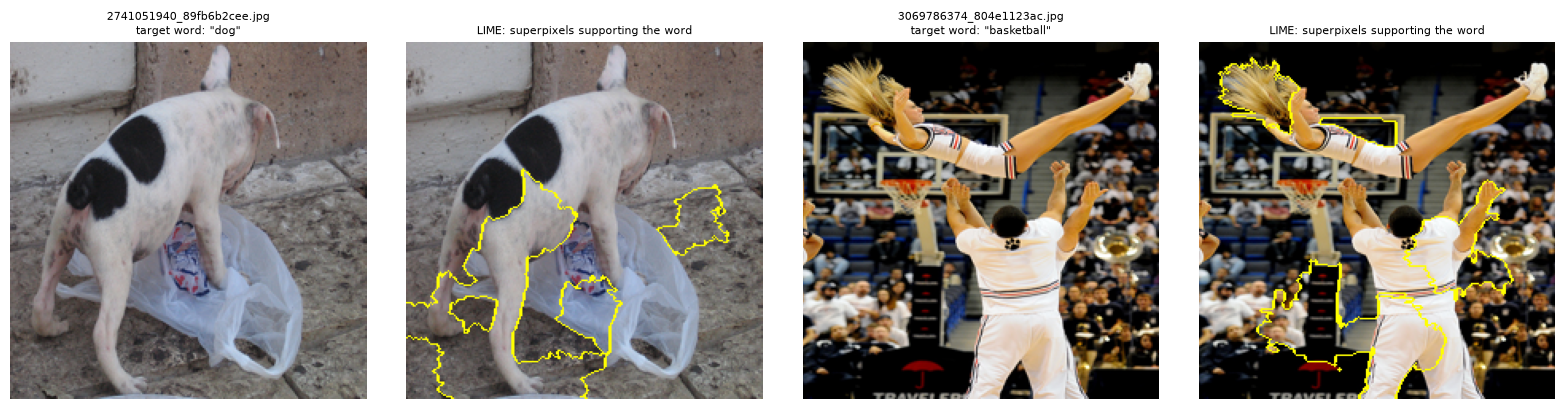

In [2]:
def lime_explain_word(img_name, caption, target_word, num_samples=80):
    image = Image.open(os.path.join(img_dir, img_name)).convert("RGB")
    input_ids = processor(text=caption, return_tensors="pt").input_ids
    tokens = [processor.tokenizer.decode([t]) for t in input_ids[0]]
    target_pos = tokens.index(target_word) - 1   # position i predicts token i+1

    @torch.no_grad()
    def classifier_fn(images_batch):
        probs = []
        for img_np in images_batch:
            pil_img = Image.fromarray(img_np.astype(np.uint8))
            pixel_values = processor(images=pil_img, return_tensors="pt").pixel_values
            outputs = model(pixel_values=pixel_values, input_ids=input_ids)
            p = F.softmax(outputs.logits[0, target_pos, :], dim=-1)[input_ids[0, target_pos + 1]].item()
            probs.append([p, 1 - p])
        return np.array(probs)

    image_np = np.array(image.resize((224, 224)))
    explainer = lime_image.LimeImageExplainer()
    explanation = explainer.explain_instance(
        image_np, classifier_fn, top_labels=1, num_samples=num_samples, batch_size=1
    )
    return image_np, explanation


LIME_CASES = [
    ("2741051940_89fb6b2cee.jpg", "a black and white dog is playing with a plastic bag.", "dog"),
    ("3069786374_804e1123ac.jpg", "two basketball players are playing basketball.", "basketball"),
]

fig, axes = plt.subplots(1, len(LIME_CASES) * 2, figsize=(8 * len(LIME_CASES), 4))
for i, (img_name, caption, target_word) in enumerate(LIME_CASES):
    image_np, explanation = lime_explain_word(img_name, caption, target_word)
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0], positive_only=True, num_features=6, hide_rest=False
    )
    axes[2 * i].imshow(image_np)
    axes[2 * i].set_title(f"{img_name}\ntarget word: \"{target_word}\"", fontsize=8)
    axes[2 * i].axis("off")
    axes[2 * i + 1].imshow(mark_boundaries(temp / 255.0, mask))
    axes[2 * i + 1].set_title("LIME: superpixels supporting the word", fontsize=8)
    axes[2 * i + 1].axis("off")

plt.tight_layout()
os.makedirs('../data/xai_examples/shap_lime', exist_ok=True)
plt.savefig('../data/xai_examples/shap_lime/lime_examples.png', dpi=120)
plt.show()

### 3. SHAP on the text prefix (3 examples: fixed case, wrong-content case, repetition-loop case)

In [3]:
def shap_explain_word(img_name, caption, target_word, nth_occurrence=0):
    image = Image.open(os.path.join(img_dir, img_name)).convert("RGB")
    pixel_values = processor(images=image, return_tensors="pt").pixel_values
    full_input_ids = processor(text=caption, return_tensors="pt").input_ids
    tokens = [processor.tokenizer.decode([t]) for t in full_input_ids[0]]

    occurrences = [i for i, t in enumerate(tokens) if t == target_word]
    target_pos = occurrences[nth_occurrence]
    prefix_words = tokens[1:target_pos]   # exclude [CLS]
    prefix_text = " ".join(prefix_words)

    @torch.no_grad()
    def f(texts):
        results = []
        for t in texts:
            words = t.split()
            word_ids = processor.tokenizer.convert_tokens_to_ids(
                processor.tokenizer.tokenize(" ".join(words))
            ) if words else []
            ids_tensor = torch.tensor([[full_input_ids[0, 0].item()] + word_ids])
            outputs = model(pixel_values=pixel_values, input_ids=ids_tensor)
            p = F.softmax(outputs.logits[0, -1, :], dim=-1)[full_input_ids[0, target_pos]].item()
            results.append(p)
        return np.array(results)

    masker = shap.maskers.Text(tokenizer=r"\s+")
    explainer = shap.Explainer(f, masker)
    return explainer([prefix_text]), prefix_text


def caption_for(img_name):
    return curated_df[curated_df["image"] == img_name]["predicted_caption"].iloc[0]


SHAP_CASES = [
    ("2741051940_89fb6b2cee.jpg", "dog", 0,
     "Fixed case: does 'white'/'black' drive the correct word 'dog'?"),
    ("3069786374_804e1123ac.jpg", "basketball", 1,
     "Wrong-content case: does the earlier 'basketball' drive the repeated one, independent of the image?"),
    ("2332986053_864db84971.jpg", "bearded", 10,
     "Repetition-loop case: is a 'bearded' token predicted mainly from prior 'bearded' tokens?"),
]

for img_name, target_word, nth, note in SHAP_CASES:
    caption = caption_for(img_name)
    print(f"=== {img_name} -- {note} ===")
    shap_values, prefix_text = shap_explain_word(img_name, caption, target_word, nth)
    print(f"Prefix: {prefix_text!r}")
    print(shap_values)
    print()

=== 2741051940_89fb6b2cee.jpg -- Fixed case: does 'white'/'black' drive the correct word 'dog'? ===


  0%|          | 0/12 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 1/1 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:40, 40.30s/it]               

Prefix: 'a black and white'
.values =
array([[0.05350188, 0.11072857, 0.14552268, 0.18148307]])

.base_values =
array([0.00756777])

.data =
(array(['a ', 'black ', 'and ', 'white'], dtype=object),)

=== 3069786374_804e1123ac.jpg -- Wrong-content case: does the earlier 'basketball' drive the repeated one, independent of the image? ===


...

Prefix: 'two basketball players are playing'
.values =
array([[-0.03127553, -0.27532372, -0.05007515, -0.06119416,  0.70579815]])

.base_values =
array([0.38784134])

.data =
(array(['two ', 'basketball ', 'players ', 'are ', 'playing'], dtype=object),)

=== 2332986053_864db84971.jpg -- Repetition-loop case: is a 'bearded' token predicted mainly from prior 'bearded' tokens? ===


  0%|          | 0/110 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 1/1 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [04:47, 287.41s/it]              

Prefix: 'a bearded bearded bearded bearded bearded bearded bearded bearded bearded bearded'
.values =
array([[ 0.03736458, -0.05573196, -0.03581268,  0.07590847,  0.00606607,
        -0.00980127,  0.03257383,  0.29574336,  0.11315016,  0.01466082,
         0.50349432]])

.base_values =
array([0.00937886])

.data =
(array(['a ', 'bearded ', 'bearded ', 'bearded ', 'bearded ', 'bearded ',
       'bearded ', 'bearded ', 'bearded ', 'bearded ', 'bearded'],
      dtype=object),)



### Observations

**LIME (image side) agrees with Day 2's Grad-CAM.** For the dog case, LIME's superpixels land on
the dog's body and the plastic bag -- the same region Grad-CAM highlighted. Two independent methods
(one gradient-based, one perturbation-based) converging on the same region is stronger evidence than
either alone that the model is genuinely grounded in the right object, not just guessing "dog"
from language priors.

**The "basketball" misclassification has a real visual cause, not just a language-model slip.**
LIME's superpixels for the word "basketball" concentrate on the standing figure -- and critically,
there's an actual basketball hoop/backboard visible in the image's background. The scene genuinely
looks like a basketball setting (hoop, gym/court environment), even though the actual subjects are
cheerleaders mid-toss. So this isn't a random miss: the model's caption is a plausible reading of
the *scene* (basketball context) that gets the *specific action* wrong (cheerleading vs. playing).

**SHAP (text side) explains the mechanism behind two very different failure types:**
- **Wrong-content case ("basketball")**: the SHAP value for the preceding word "playing" is large
  and positive (+0.71), while the earlier "basketball" token is *negative* (-0.28) -- the dominant
  driver is the "playing ___" collocation itself, not literal repetition of the earlier word. This
  is a language-model prior ("playing" strongly primes "basketball" as a continuation) reinforcing
  what the hoop in the background already visually suggested.
- **Repetition-loop case ("bearded")**: SHAP tells a completely different story. The immediately
  preceding "bearded" token dominates the prediction (SHAP value 0.50, dwarfing every other word in
  the 10-word prefix). This is the text-side signature of the same problem Day 2's Grad-CAM found
  from the vision side (attention stuck on background texture, disengaged from the face) --
  together they show the model has fallen into a self-reinforcing loop where the last token
  predicts itself, with essentially no contribution from the image or earlier context. Confirms
  Day 2's conclusion: this needs a decoding-time fix (repetition penalty / no-repeat-ngram), not
  more fine-tuning.

**Takeaway across both days:** "poor" captions come in at least two distinct flavors that look
identical from the BLEU/ROUGE score alone but need different fixes -- (1) plausible
misidentification driven by genuine, converging visual+language cues (needs more/better training
data or context disambiguation), and (2) decoding degeneration where the model stops using the
image entirely (needs a generation-time constraint, not retraining).